In [3]:
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import (RocCurveDisplay, ConfusionMatrixDisplay, classification_report)
from sklearn.model_selection import cross_val_score
import sys
sys.path.append('../src')
from data import get_processed_data

# Load model and data
model = joblib.load('../models/best_model.pkl')
X_train, X_test, y_train, y_test = get_processed_data()

from data import load_data
X, y = load_data()
cv_scores = cross_val_score(model, X, y, cv=5, scoring='roc_auc')
print(f"CV ROC-AUC scores: {cv_scores}")
print(f"Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

CV ROC-AUC scores: [0.90367965 0.96645022 0.89935065 0.92031425 0.89508929]
Mean: 0.9170 (+/- 0.0262)


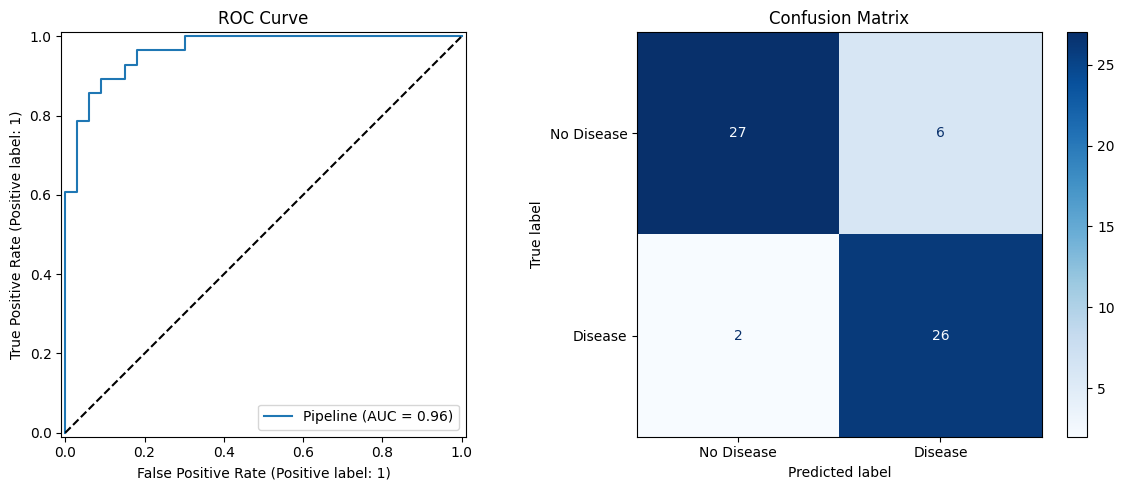

              precision    recall  f1-score   support

  No Disease       0.93      0.82      0.87        33
     Disease       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC Curve
RocCurveDisplay.from_estimator(model, X_test, y_test, ax=axes[0])
axes[0].set_title('ROC Curve')
axes[0].plot([0,1], [0,1], 'k--')

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    model, X_test, y_test,
    display_labels=['No Disease', 'Disease'],
    cmap='Blues', ax=axes[1]
)
axes[1].set_title('Confusion Matrix')

plt.tight_layout()
plt.savefig('../data/raw/model_evaluation.png', dpi=150)
plt.show()

print(classification_report(y_test, model.predict(X_test), target_names=['No Disease', 'Disease']))